Epoch [1000/10000], Loss: 0.0027
Epoch [2000/10000], Loss: 0.0008
Epoch [3000/10000], Loss: 0.0005
Epoch [4000/10000], Loss: 0.0003
Epoch [5000/10000], Loss: 0.0002
Epoch [6000/10000], Loss: 0.0002
Epoch [7000/10000], Loss: 0.0001
Epoch [8000/10000], Loss: 0.0001
Epoch [9000/10000], Loss: 0.0001
Epoch [10000/10000], Loss: 0.0001


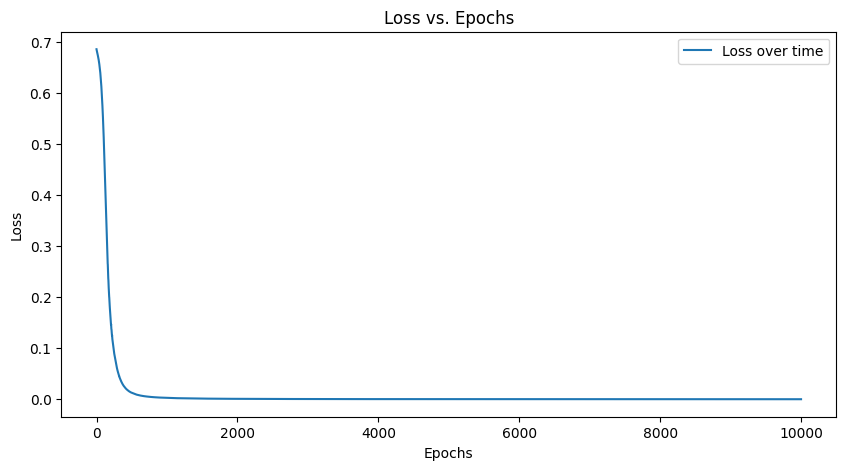

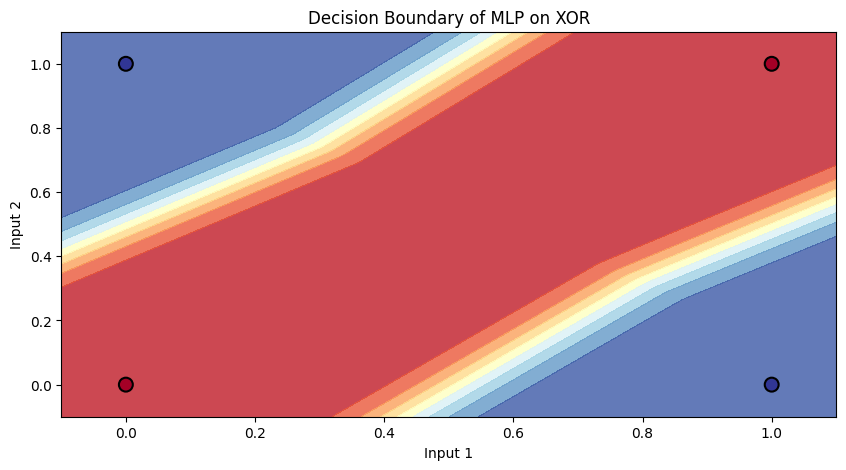

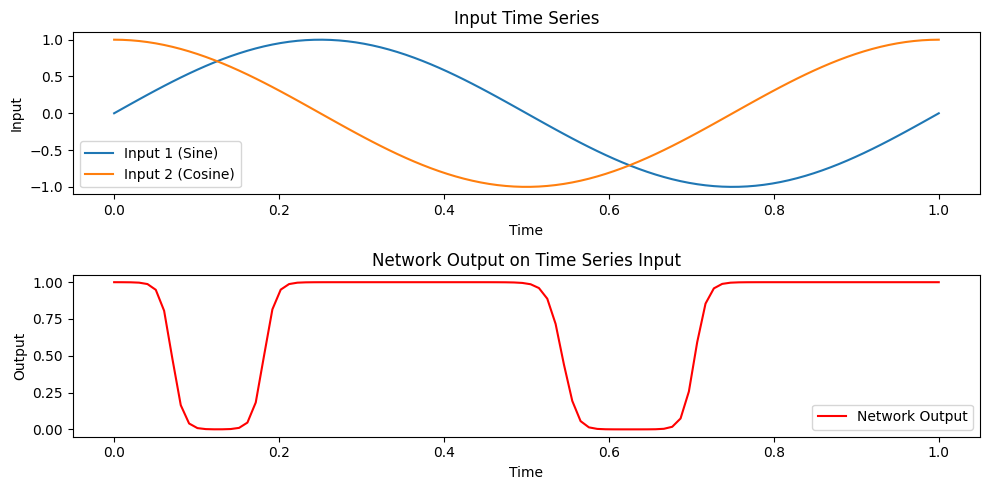

In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# Define the feedforward neural network (MLP)
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(2, 10)  # Input layer (2 input features)
        self.fc2 = nn.Linear(10, 10) # Hidden layer
        self.fc3 = nn.Linear(10, 1)  # Output layer

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        return x

# Create the XOR dataset
data = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
labels = torch.tensor([[0.], [1.], [1.], [0.]])

# Initialize the model, loss function, and optimizer
model = MLP()
criterion = nn.BCELoss()  # Binary Cross Entropy Loss for binary classification
optimizer = optim.SGD(model.parameters(), lr=0.1)

# Track loss for visualization
losses = []

# Training the model
epochs = 10000
for epoch in range(epochs):
    # Zero the gradients
    optimizer.zero_grad()

    # Forward pass
    outputs = model(data)
    loss = criterion(outputs, labels)
    losses.append(loss.item())  # Record loss

    # Backward pass and optimize
    loss.backward()
    optimizer.step()

    # Print loss every 1000 epochs
    if (epoch+1) % 1000 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

# Plotting loss over epochs
plt.figure(figsize=(10, 5))
plt.plot(losses, label="Loss over time")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs. Epochs')
plt.legend()
plt.show()

# Visualize decision boundary
def plot_decision_boundary(model, data, labels):
    # Generate a grid of points over the input space
    x_min, x_max = data[:, 0].min() - 0.1, data[:, 0].max() + 0.1
    y_min, y_max = data[:, 1].min() - 0.1, data[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    
    # Convert grid to tensor and get model predictions
    grid_points = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    with torch.no_grad():
        Z = model(grid_points)
    Z = Z.reshape(xx.shape).numpy()

    # Plot contour map and data points
    plt.figure(figsize=(10, 5))
    plt.contourf(xx, yy, Z, alpha=0.8, levels=np.linspace(0, 1, 10), cmap=plt.cm.RdYlBu)
    plt.scatter(data[:, 0], data[:, 1], c=labels[:, 0], s=100, edgecolors='k', linewidth=1.5, cmap=plt.cm.RdYlBu)
    plt.xlabel('Input 1')
    plt.ylabel('Input 2')
    plt.title('Decision Boundary of MLP on XOR')
    plt.show()

# Call the decision boundary visualization function
plot_decision_boundary(model, data, labels)

# Test the network on two input time series ranging between 0 and 1
# Generate time series data (sine waves)
t = np.linspace(0, 1, 100)
input1 = np.sin(2 * np.pi * t)  # Sine wave
input2 = np.cos(2 * np.pi * t)  # Cosine wave

# Stack inputs into a single tensor
time_series_input = torch.tensor(np.c_[input1, input2], dtype=torch.float32)

# Pass the time series data through the model
with torch.no_grad():
    time_series_output = model(time_series_input)

# Convert the output to numpy for visualization
time_series_output = time_series_output.numpy()

# Plot the input time series and the network output
plt.figure(figsize=(10, 5))

plt.subplot(2, 1, 1)
plt.plot(t, input1, label="Input 1 (Sine)")
plt.plot(t, input2, label="Input 2 (Cosine)")
plt.xlabel('Time')
plt.ylabel('Input')
plt.title('Input Time Series')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t, time_series_output, label="Network Output", color='r')
plt.xlabel('Time')
plt.ylabel('Output')
plt.title('Network Output on Time Series Input')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
#make the loss manifold and show with changes in weight to learn seccond task is 
# less while we have spatially biased baselines

#test it with different directions

In [ ]:
# test how important is the spatial organization of bias

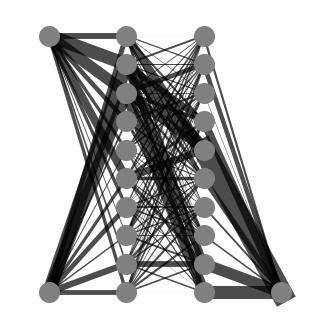

In [31]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def visualize_network_structure(model):
    """
    Visualizes the neural network structure with weights represented as line thickness.
    Each neuron is represented as a gray node, and the connections between them are represented
    by lines with thickness proportional to the weight magnitude. The network structure is
    dynamically inferred from the model.
    """
    # Get the model's parameters
    params = list(model.named_parameters())
    
    # Automatically infer the number of layers and neurons from the model
    layer_sizes = []
    for name, param in model.named_parameters():
        if 'weight' in name:
            layer_sizes.append(param.shape[1])  # Number of input neurons to the layer
    
    # Add the number of output neurons from the last layer
    layer_sizes.append(params[-2][1].shape[0])  # The last weight matrix determines the output neurons
    
    # Define layer positions based on the number of layers
    layer_positions = list(range(1, len(layer_sizes) + 1))
    
    # Generate neuron positions based on the number of neurons in each layer
    neuron_positions = [np.linspace(0, 1, size) for size in layer_sizes]

    # Increase figure size for better visibility
    fig, ax = plt.subplots(figsize=(4, 4))

    # Plot connections (lines) based on weights first
    for i, (name, param) in enumerate(params):
        if 'weight' in name:
            # Get the weight matrix as a NumPy array
            weight_matrix = param.detach().numpy()
            layer_idx = i // 2  # Every weight corresponds to a layer
            
            # For each connection, draw a line with thickness proportional to the weight magnitude
            for j in range(weight_matrix.shape[0]):  # Iterate over output neurons
                for k in range(weight_matrix.shape[1]):  # Iterate over input neurons
                    x = [layer_positions[layer_idx], layer_positions[layer_idx + 1]]
                    y = [neuron_positions[layer_idx][k], neuron_positions[layer_idx + 1][j]]
                    
                    # Line thickness is proportional to the absolute value of the weight
                    line_thickness = np.abs(weight_matrix[j, k]) * 5
                    ax.plot(x, y, 'k-', lw=line_thickness, alpha=0.7)

    # Plot neurons (gray circles) on top of the lines
    for layer_idx, positions in enumerate(neuron_positions):
        ax.scatter([layer_positions[layer_idx]]*len(positions), positions, s=200, color='gray', zorder=3)

    # Remove the axis for a cleaner look
    plt.axis('off')

    # Set plot limits
    ax.set_xlim(0.5, len(layer_sizes) + 0.5)
    ax.set_ylim(-0.1, 1.1)

    # Show the plot
    plt.show()

'''
# Example MLP model with dynamic structure
class MLP(torch.nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = torch.nn.Linear(2, 10)  # Input layer (2 input features)
        self.fc2 = torch.nn.Linear(10, 5)  # Hidden layer (5 neurons)
        self.fc3 = torch.nn.Linear(5, 1)   # Output layer (1 neuron)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        return x

# Instantiate the model
model = MLP()
'''

# Visualize the network structure with its weights
visualize_network_structure(model)


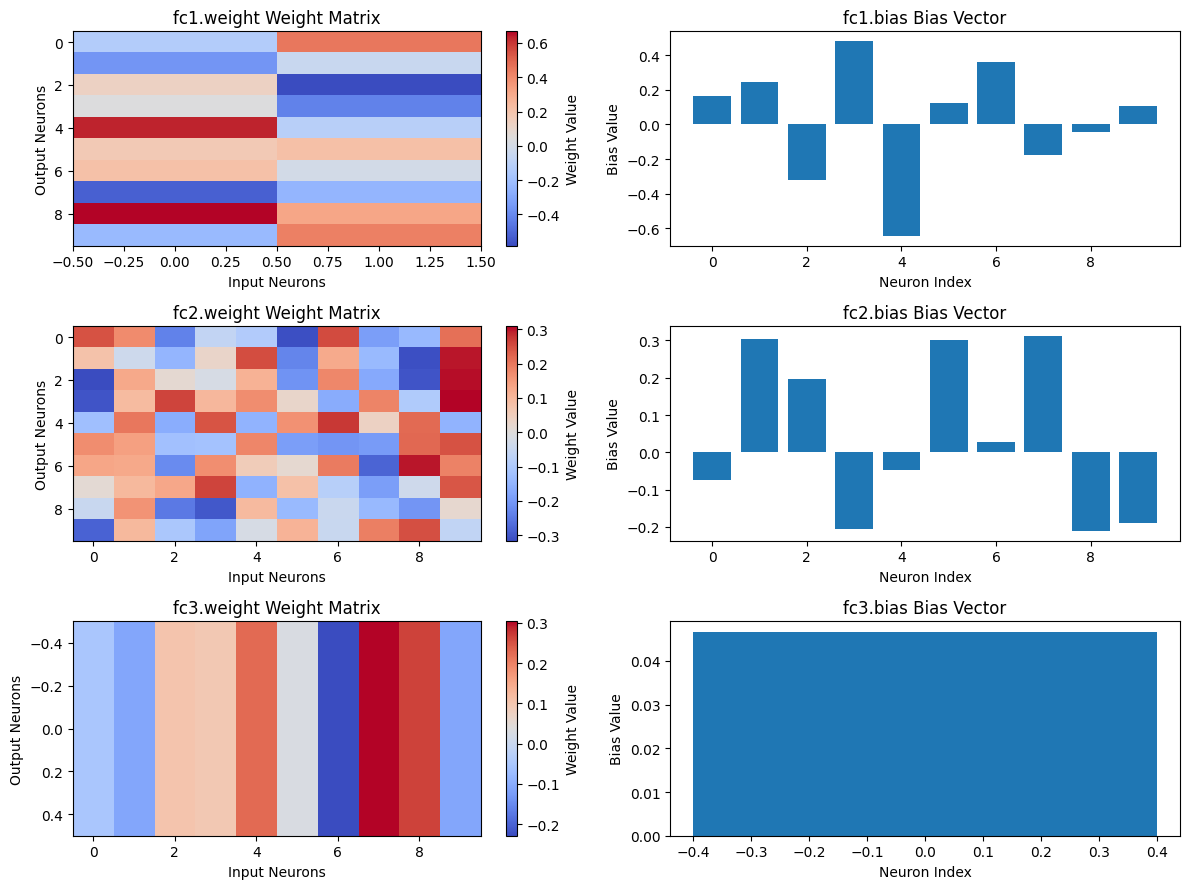

In [32]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def visualize_weights_and_biases(model):
    """
    Visualizes the weights and biases of a given feedforward neural network (MLP) as a n x 2 subplot layout.
    Each layer's weights are plotted as a heatmap in the left column, and biases are visualized as a bar plot in the right column.
    """
    # Get the model's parameters
    params = list(model.named_parameters())
    
    # Determine the number of layers in the model
    num_layers = len(params) // 2  # We have both weights and biases for each layer
    
    # Create a figure with subplots (n x 2 layout, where n is the number of layers)
    fig, axes = plt.subplots(nrows=num_layers, ncols=2, figsize=(12, num_layers * 3))
    
    # Iterate through the parameters
    for i in range(num_layers):
        # Plot weights in the left column
        weight_name, weight_matrix = params[i * 2]  # Weight matrix for the layer
        weight_matrix = weight_matrix.detach().numpy()  # Convert to NumPy array
        cax = axes[i, 0].imshow(weight_matrix, cmap='coolwarm', aspect='auto')
        fig.colorbar(cax, ax=axes[i, 0], label='Weight Value')
        axes[i, 0].set_title(f'{weight_name} Weight Matrix')
        axes[i, 0].set_xlabel('Input Neurons')
        axes[i, 0].set_ylabel('Output Neurons')
        
        # Plot biases in the right column
        bias_name, bias_vector = params[i * 2 + 1]  # Bias vector for the layer
        bias_vector = bias_vector.detach().numpy()  # Convert to NumPy array
        axes[i, 1].bar(np.arange(len(bias_vector)), bias_vector)
        axes[i, 1].set_title(f'{bias_name} Bias Vector')
        axes[i, 1].set_xlabel('Neuron Index')
        axes[i, 1].set_ylabel('Bias Value')

    # Adjust layout
    plt.tight_layout()
    plt.show()

# Instantiate the model again to visualize its weights and biases
model = MLP()

# Visualize weights and biases of the model
visualize_weights_and_biases(model)


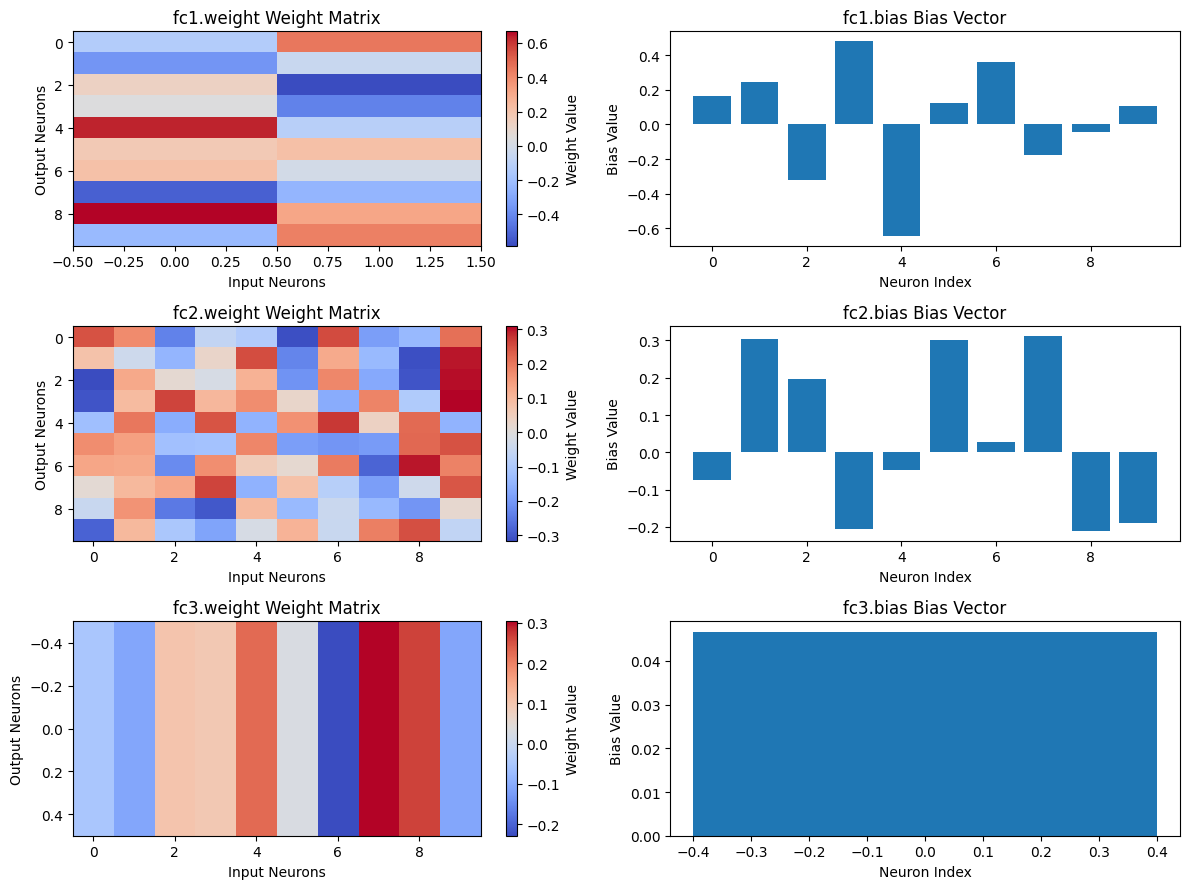

In [33]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def visualize_weights_and_biases(model):
    """
    Visualizes the weights and biases of a given feedforward neural network (MLP) as a n x 2 subplot layout.
    Each layer's weights are plotted as a heatmap in the left column, and biases are visualized as a bar plot in the right column.
    """
    # Get the model's parameters
    params = list(model.named_parameters())
    
    # Determine the number of layers by counting weight matrices (assumes weights and biases alternate)
    num_layers = len(params) // 2  # Each layer has a weight and a bias
    
    # Create a figure with subplots (n x 2 layout, where n is the number of layers)
    fig, axes = plt.subplots(nrows=num_layers, ncols=2, figsize=(12, num_layers * 3))
    
    # Iterate through the parameters (weights and biases)
    for i in range(num_layers):
        # Plot weights in the left column
        weight_name, weight_matrix = params[i * 2]  # Weight matrix for the layer
        weight_matrix = weight_matrix.detach().numpy()  # Convert to NumPy array
        cax = axes[i, 0].imshow(weight_matrix, cmap='coolwarm', aspect='auto')
        fig.colorbar(cax, ax=axes[i, 0], label='Weight Value')
        axes[i, 0].set_title(f'{weight_name} Weight Matrix')
        axes[i, 0].set_xlabel('Input Neurons')
        axes[i, 0].set_ylabel('Output Neurons')
        
        # Plot biases in the right column
        bias_name, bias_vector = params[i * 2 + 1]  # Bias vector for the layer
        bias_vector = bias_vector.detach().numpy()  # Convert to NumPy array
        axes[i, 1].bar(np.arange(len(bias_vector)), bias_vector)
        axes[i, 1].set_title(f'{bias_name} Bias Vector')
        axes[i, 1].set_xlabel('Neuron Index')
        axes[i, 1].set_ylabel('Bias Value')

    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()


# Visualize weights and biases of the model
visualize_weights_and_biases(model)


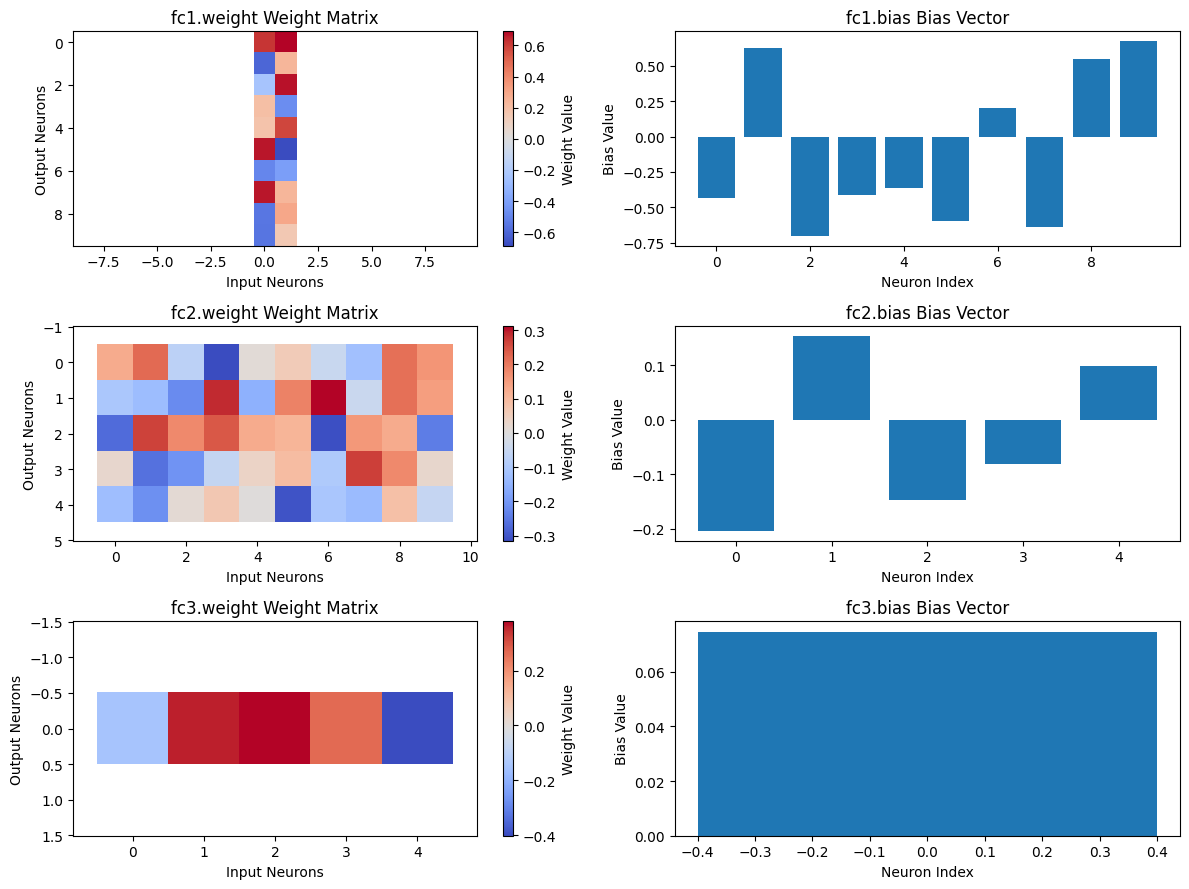

In [35]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def visualize_weights_and_biases(model):
    """
    Visualizes the weights and biases of a given feedforward neural network (MLP) as an n x 2 subplot layout.
    Each layer's weights are plotted as a heatmap in the left column, and biases are visualized as a bar plot in the right column.
    """
    # Get the model's parameters
    params = list(model.named_parameters())
    
    # Prepare lists for weights and biases
    weights = []
    biases = []
    
    # Iterate through parameters and separate weights and biases
    for name, param in params:
        if 'weight' in name:
            weights.append((name, param))
        elif 'bias' in name:
            biases.append((name, param))
    
    # Ensure we have the same number of weights and biases (assuming each layer has both)
    num_layers = len(weights)
    
    # Create a figure with subplots (n x 2 layout, where n is the number of layers)
    fig, axes = plt.subplots(nrows=num_layers, ncols=2, figsize=(12, num_layers * 3))
    
    # Iterate through the layers
    for i in range(num_layers):
        # Plot weights in the left column
        weight_name, weight_matrix = weights[i]  # Get the weight matrix
        weight_matrix = weight_matrix.detach().numpy()  # Convert to NumPy array
        cax = axes[i, 0].imshow(weight_matrix, cmap='coolwarm', aspect='auto')
        fig.colorbar(cax, ax=axes[i, 0], label='Weight Value')
        axes[i, 0].set_title(f'{weight_name} Weight Matrix')
        axes[i, 0].set_xlabel('Input Neurons')
        axes[i, 0].set_ylabel('Output Neurons')
        axes[i,0].axis('equal')
        
        # Plot biases in the right column (only if biases exist)
        if i < len(biases):
            bias_name, bias_vector = biases[i]  # Get the bias vector
            bias_vector = bias_vector.detach().numpy()  # Convert to NumPy array
            axes[i, 1].bar(np.arange(len(bias_vector)), bias_vector)
            axes[i, 1].set_title(f'{bias_name} Bias Vector')
            axes[i, 1].set_xlabel('Neuron Index')
            axes[i, 1].set_ylabel('Bias Value')
        else:
            # If there's no bias, clear the axis
            axes[i, 1].axis('off')
    
    # Adjust layout
    plt.tight_layout()
    plt.show()

# Example MLP model with dynamic structure
class MLP(torch.nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = torch.nn.Linear(2, 10)  # Input layer (2 input features)
        self.fc2 = torch.nn.Linear(10, 5)  # Hidden layer (5 neurons)
        self.fc3 = torch.nn.Linear(5, 1)   # Output layer (1 neuron)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        return x

# Instantiate the model again to visualize its weights and biases
model = MLP()

# Visualize weights and biases of the model
visualize_weights_and_biases(model)
